In [13]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MOTIF_DISCOVERY_DIR = OUTPUT_DIR / "motif_discovery"

PHASE_G_DIR = OUTPUT_DIR / "energy_analysis"
FIGURE_DIR = PHASE_G_DIR / "figures"
TABLE_DIR = PHASE_G_DIR / "tables"
TEXT_DIR = PHASE_G_DIR / "text"

for path in [PHASE_G_DIR, FIGURE_DIR, TABLE_DIR, TEXT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# ============================================================
# Input files
# ============================================================

MASTER_CSV = OUTPUT_DIR / "dataset_master.csv"
PHASE_F_PRIMARY_CSV = MOTIF_DISCOVERY_DIR / "cluster_assignments_primary.csv"

# Optional supporting files
MOTIF_SUMMARY_CSV = MOTIF_DISCOVERY_DIR / "motif_cluster_summary.csv"
MOTIF_REPRESENTATIVES_CSV = MOTIF_DISCOVERY_DIR / "motif_representatives.csv"
MOTIF_STABILITY_CSV = MOTIF_DISCOVERY_DIR / "motif_stability_summary.csv"

# ============================================================
# Scientific constants
# ============================================================

STABLE_ENERGY = -936.6398

# You can tune these later if needed
NEAR_STABLE_MAX = 0.15
MODERATELY_UNSTABLE_MAX = 0.50

# ============================================================
# Plot style
# ============================================================

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [15]:
def require_file(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")


def save_df(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    df.to_csv(path, index=False)
    return df


def save_json(obj: dict, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def classify_energy_state(delta_e: float) -> str:
    if pd.isna(delta_e):
        return "unknown"
    if delta_e <= NEAR_STABLE_MAX:
        return "near_stable"
    if delta_e <= MODERATELY_UNSTABLE_MAX:
        return "moderately_unstable"
    return "highly_unstable"


def get_clustered_only(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["cluster"].notna() & (df["cluster"] != -1)].copy()


def effect_size_eta_squared_from_kruskal(h_stat: float, n: int, k: int) -> float:
    if n <= k:
        return np.nan
    return max((h_stat - k + 1) / (n - k), 0.0)


def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    return (gt - lt) / (len(x) * len(y))


def holm_adjust(p_values: list[float]) -> list[float]:
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m, dtype=float)

    for rank, idx in enumerate(order):
        adjusted[idx] = min((m - rank) * p[idx], 1.0)

    sorted_adj = adjusted[order].copy()
    for i in range(1, m):
        sorted_adj[i] = max(sorted_adj[i], sorted_adj[i - 1])

    adjusted[order] = np.clip(sorted_adj, 0, 1)
    return adjusted.tolist()

In [16]:
def build_phase_g_master_table() -> pd.DataFrame:
    require_file(PHASE_F_PRIMARY_CSV)

    df = pd.read_csv(PHASE_F_PRIMARY_CSV).copy()

    # ------------------------------------------------------------
    # Standardize cluster columns
    # ------------------------------------------------------------
    df = df.rename(
        columns={
            "cluster_label": "cluster",
            "cluster_confidence": "cluster_confidence",
        }
    )

    # ------------------------------------------------------------
    # Use existing energy columns if present, otherwise recompute
    # ------------------------------------------------------------
    if "energy" in df.columns:
        df["energy"] = pd.to_numeric(df["energy"], errors="coerce")
    elif "energy_master" in df.columns:
        df["energy"] = pd.to_numeric(df["energy_master"], errors="coerce")
    else:
        raise ValueError("No usable energy column found.")

    if "delta_energy" in df.columns:
        df["delta_energy"] = pd.to_numeric(df["delta_energy"], errors="coerce")
    elif "delta_energy_master" in df.columns:
        df["delta_energy"] = pd.to_numeric(df["delta_energy_master"], errors="coerce")
    else:
        df["delta_energy"] = df["energy"] - STABLE_ENERGY

    df["stable_energy"] = STABLE_ENERGY
    df["energy_state"] = df["delta_energy"].apply(classify_energy_state)

    # ------------------------------------------------------------
    # Ensure cluster dtype is numeric nullable integer
    # ------------------------------------------------------------
    df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce").astype("Int64")

    if "cluster_confidence" in df.columns:
        df["cluster_confidence"] = pd.to_numeric(df["cluster_confidence"], errors="coerce")
    else:
        df["cluster_confidence"] = np.nan

    # ------------------------------------------------------------
    # Standard flags
    # ------------------------------------------------------------
    df["is_clustered"] = df["cluster"].notna()
    df["is_noise"] = df["cluster"].fillna(-999).astype("Int64") == -1

    return df

In [17]:
df_phase_g = build_phase_g_master_table()

print("=" * 70)
print("PHASE G MASTER TABLE")
print("=" * 70)
print(f"Rows                    : {len(df_phase_g)}")
print(f"Columns                 : {len(df_phase_g.columns)}")
print(f"Clustered rows          : {int(df_phase_g['is_clustered'].sum())}")
print(f"Noise rows (cluster=-1) : {int(df_phase_g['is_noise'].sum())}")
print(f"Missing energy          : {int(df_phase_g['energy'].isna().sum())}")
print(f"Missing delta_energy    : {int(df_phase_g['delta_energy'].isna().sum())}")
print("=" * 70)

save_df(df_phase_g, TABLE_DIR / "phase_g_master_table.csv")
df_phase_g.head()

PHASE G MASTER TABLE
Rows                    : 2916
Columns                 : 207
Clustered rows          : 2916
Noise rows (cluster=-1) : 1486
Missing energy          : 0
Missing delta_energy    : 0


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,umap_2,tsne_1,tsne_2,cluster_method,cluster,cluster_confidence,stable_energy,energy_state,is_clustered,is_noise
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,-9.693111,16.256012,18.173557,hdbscan,2,0.878092,-936.6398,near_stable,True,False
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,-9.549086,33.514286,17.762970,hdbscan,2,0.898457,-936.6398,moderately_unstable,True,False
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,-9.504131,28.649391,20.207617,hdbscan,2,0.945606,-936.6398,moderately_unstable,True,False
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,-9.060636,15.751867,13.407825,hdbscan,-1,0.000000,-936.6398,moderately_unstable,True,True
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,-8.496241,-14.410838,7.230876,hdbscan,2,0.951519,-936.6398,highly_unstable,True,False


In [18]:
df_task31 = df_phase_g.copy()

summary_task31 = {
    "stable_energy": STABLE_ENERGY,
    "num_structures": int(len(df_task31)),
    "num_missing_energy": int(df_task31["energy"].isna().sum()),
    "min_energy": float(df_task31["energy"].min()),
    "max_energy": float(df_task31["energy"].max()),
    "mean_energy": float(df_task31["energy"].mean()),
    "min_delta_energy": float(df_task31["delta_energy"].min()),
    "max_delta_energy": float(df_task31["delta_energy"].max()),
    "mean_delta_energy": float(df_task31["delta_energy"].mean()),
    "std_delta_energy": float(df_task31["delta_energy"].std(ddof=0)),
    "near_stable_max": NEAR_STABLE_MAX,
    "moderately_unstable_max": MODERATELY_UNSTABLE_MAX,
    "near_stable_count": int((df_task31["energy_state"] == "near_stable").sum()),
    "moderately_unstable_count": int((df_task31["energy_state"] == "moderately_unstable").sum()),
    "highly_unstable_count": int((df_task31["energy_state"] == "highly_unstable").sum()),
}

save_json(summary_task31, TEXT_DIR / "task31_energy_summary.json")

energy_state_counts = (
    df_task31["energy_state"]
    .value_counts(dropna=False)
    .rename_axis("energy_state")
    .reset_index(name="count")
)
save_df(energy_state_counts, TABLE_DIR / "task31_energy_state_counts.csv")

print(json.dumps(summary_task31, indent=2))
energy_state_counts

{
  "stable_energy": -936.6398,
  "num_structures": 2916,
  "num_missing_energy": 0,
  "min_energy": -937.249267578125,
  "max_energy": -935.906005859375,
  "mean_energy": -936.3141890370142,
  "min_delta_energy": -0.6094800233840942,
  "max_delta_energy": 0.7337999939918518,
  "mean_delta_energy": 0.32561102546367443,
  "std_delta_energy": 0.23593115123293876,
  "near_stable_max": 0.15,
  "moderately_unstable_max": 0.5,
  "near_stable_count": 542,
  "moderately_unstable_count": 1655,
  "highly_unstable_count": 719
}


,energy_state,count
0,moderately_unstable,1655
1,highly_unstable,719
2,near_stable,542


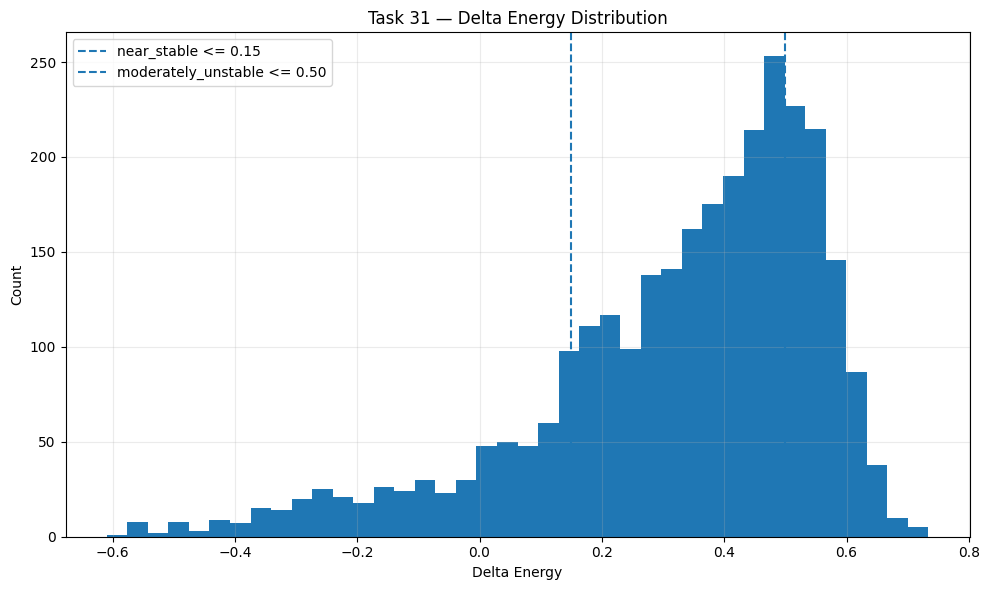

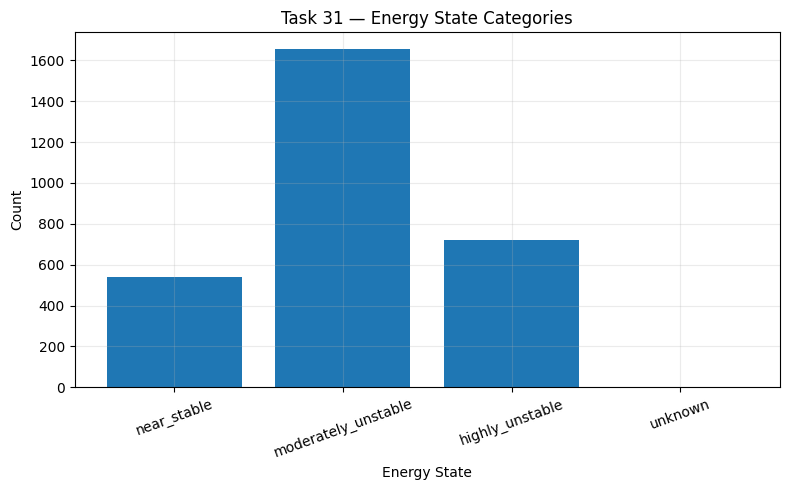

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_task31["delta_energy"].dropna(), bins=40)
ax.axvline(NEAR_STABLE_MAX, linestyle="--", label=f"near_stable <= {NEAR_STABLE_MAX:.2f}")
ax.axvline(MODERATELY_UNSTABLE_MAX, linestyle="--", label=f"moderately_unstable <= {MODERATELY_UNSTABLE_MAX:.2f}")
ax.set_title("Task 31 — Delta Energy Distribution")
ax.set_xlabel("Delta Energy")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task31_delta_energy_histogram.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
state_order = ["near_stable", "moderately_unstable", "highly_unstable", "unknown"]
counts = df_task31["energy_state"].value_counts().reindex(state_order).fillna(0)
ax.bar(counts.index, counts.values)
ax.set_title("Task 31 — Energy State Categories")
ax.set_xlabel("Energy State")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task31_energy_state_bar.png", dpi=300)
plt.show()

In [20]:
df_clustered = get_clustered_only(df_phase_g)

cluster_energy_summary = (
    df_clustered
    .groupby("cluster", dropna=False)
    .agg(
        n_structures=("structure_id", "count"),
        mean_energy=("energy", "mean"),
        std_energy=("energy", "std"),
        min_energy=("energy", "min"),
        max_energy=("energy", "max"),
        mean_delta_energy=("delta_energy", "mean"),
        std_delta_energy=("delta_energy", "std"),
        min_delta_energy=("delta_energy", "min"),
        max_delta_energy=("delta_energy", "max"),
        median_delta_energy=("delta_energy", "median"),
        frac_near_stable=("energy_state", lambda s: (s == "near_stable").mean()),
        frac_moderately_unstable=("energy_state", lambda s: (s == "moderately_unstable").mean()),
        frac_highly_unstable=("energy_state", lambda s: (s == "highly_unstable").mean()),
        mean_cluster_confidence=("cluster_confidence", "mean"),
    )
    .reset_index()
    .sort_values(["mean_delta_energy", "frac_near_stable"], ascending=[True, False])
    .reset_index(drop=True)
)

save_df(cluster_energy_summary, TABLE_DIR / "task32_cluster_energy_summary.csv")
cluster_energy_summary.head(10)

,cluster,n_structures,mean_energy,std_energy,min_energy,max_energy,mean_delta_energy,std_delta_energy,min_delta_energy,max_delta_energy,median_delta_energy,frac_near_stable,frac_moderately_unstable,frac_highly_unstable,mean_cluster_confidence
0,2,1342,-936.312050,0.229416,-937.059387,-935.906006,0.327750,0.229416,-0.41960,0.73380,0.38625,0.184799,0.586438,0.228763,0.950868
1,0,41,-936.224338,0.087376,-936.386414,-936.045593,0.415461,0.087375,0.25337,0.59419,0.41350,0.000000,0.804878,0.195122,0.996375
2,1,47,-936.209619,0.123761,-936.639771,-936.067322,0.430182,0.123769,0.00000,0.57250,0.45629,0.063830,0.723404,0.212766,0.990480


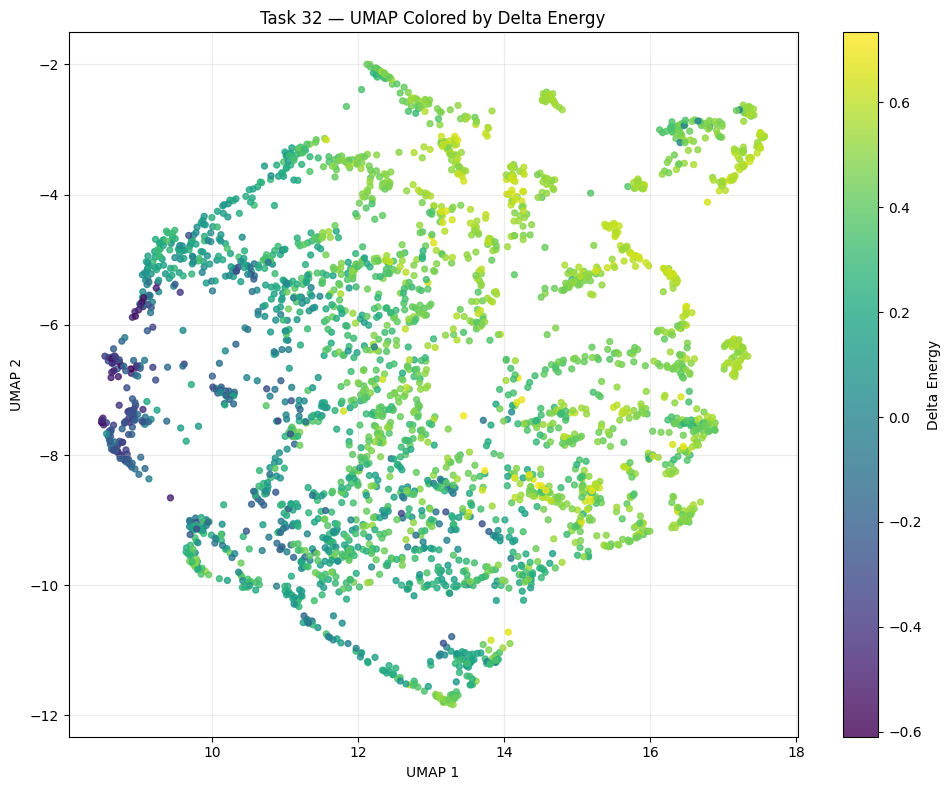

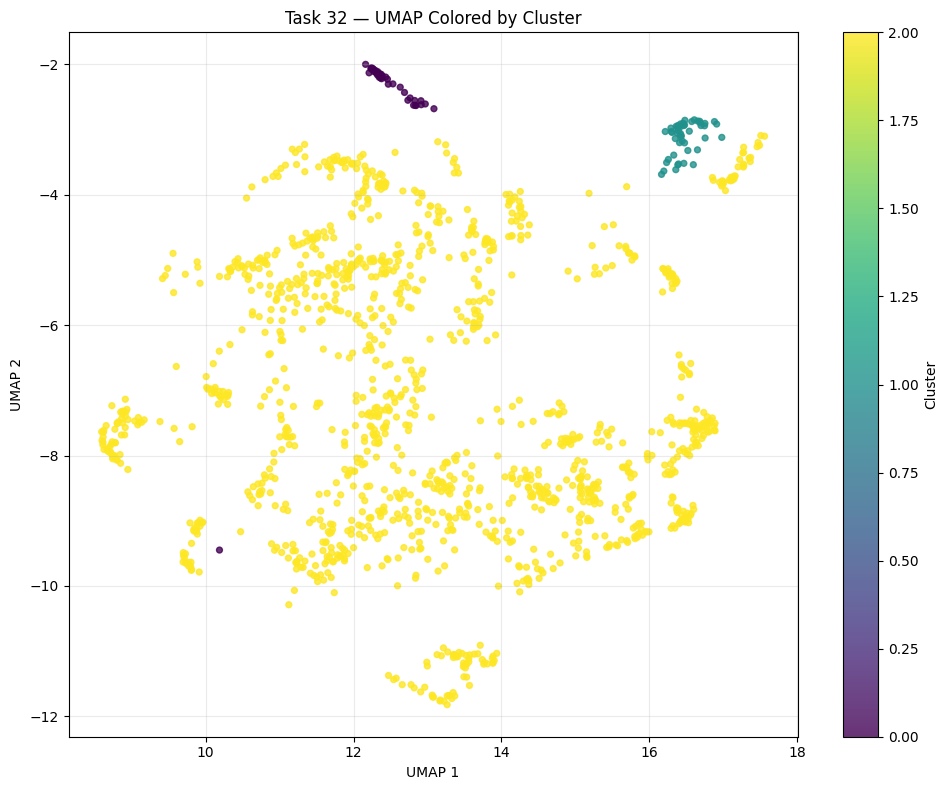

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df_phase_g["umap_1"],
    df_phase_g["umap_2"],
    c=df_phase_g["delta_energy"],
    s=18,
    alpha=0.8,
)
ax.set_title("Task 32 — UMAP Colored by Delta Energy")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Delta Energy")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task32_umap_colored_by_delta_energy.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df_clustered["umap_1"],
    df_clustered["umap_2"],
    c=df_clustered["cluster"].astype(int),
    s=18,
    alpha=0.8,
)
ax.set_title("Task 32 — UMAP Colored by Cluster")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Cluster")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task32_umap_colored_by_cluster.png", dpi=300)
plt.show()

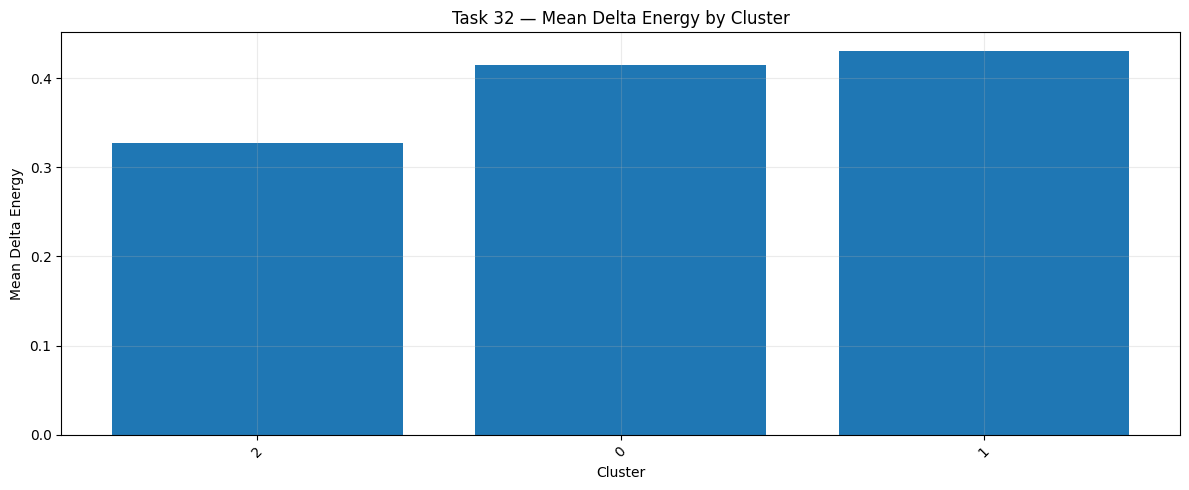

C:\Users\mcham\AppData\Local\Temp\ipykernel_29908\849009727.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(c) for c in cluster_ids], showfliers=False)


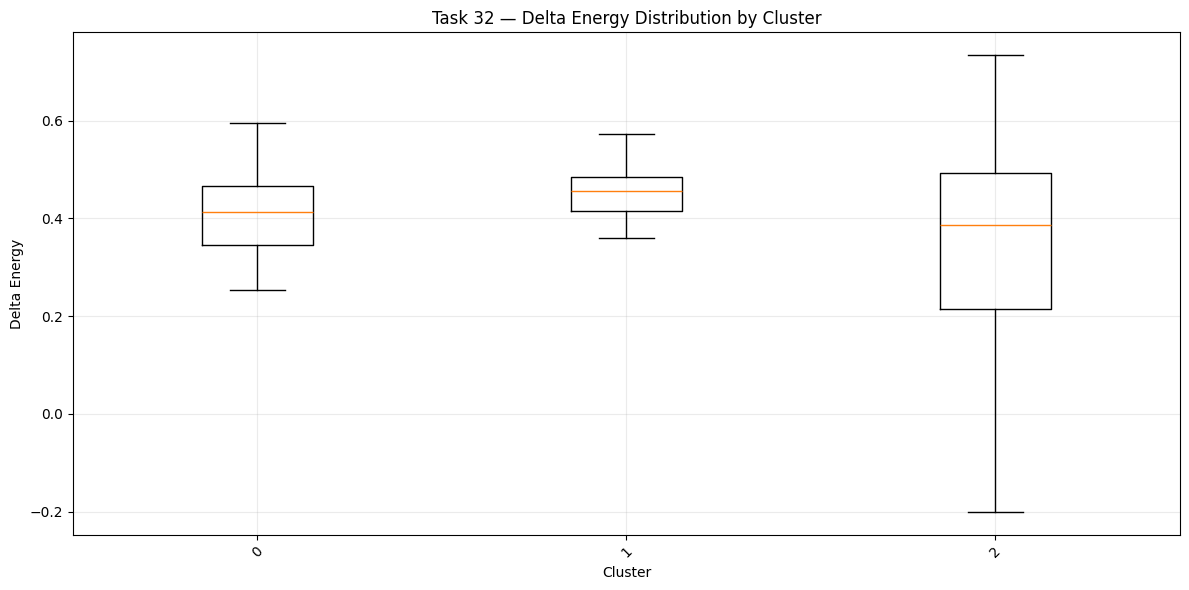

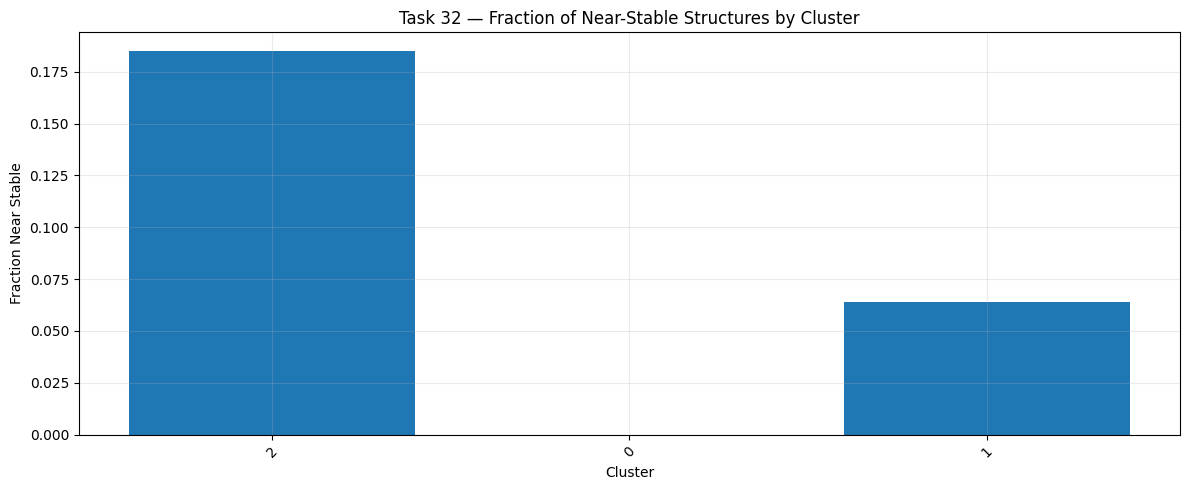

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    cluster_energy_summary["cluster"].astype(str),
    cluster_energy_summary["mean_delta_energy"],
)
ax.set_title("Task 32 — Mean Delta Energy by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean Delta Energy")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task32_mean_delta_energy_by_cluster.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
cluster_ids = sorted(df_clustered["cluster"].dropna().astype(int).unique().tolist())
data = [
    df_clustered.loc[df_clustered["cluster"].astype(int) == c, "delta_energy"].dropna().values
    for c in cluster_ids
]
ax.boxplot(data, labels=[str(c) for c in cluster_ids], showfliers=False)
ax.set_title("Task 32 — Delta Energy Distribution by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Delta Energy")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task32_delta_energy_boxplot_by_cluster.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    cluster_energy_summary["cluster"].astype(str),
    cluster_energy_summary["frac_near_stable"],
)
ax.set_title("Task 32 — Fraction of Near-Stable Structures by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Fraction Near Stable")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task32_fraction_near_stable_by_cluster.png", dpi=300)
plt.show()

In [23]:
top_motif_families = cluster_energy_summary.copy()

top_motif_families["stability_rank"] = (
    top_motif_families["mean_delta_energy"].rank(method="dense", ascending=True).astype(int)
)
top_motif_families["near_stable_rank"] = (
    top_motif_families["frac_near_stable"].rank(method="dense", ascending=False).astype(int)
)

top_motif_families["combined_score"] = (
    0.7 * top_motif_families["mean_delta_energy"].rank(pct=True, ascending=True)
    + 0.3 * top_motif_families["frac_near_stable"].rank(pct=True, ascending=False)
)

top_motif_families = top_motif_families.sort_values(
    ["combined_score", "mean_delta_energy", "frac_near_stable"],
    ascending=[True, True, False],
).reset_index(drop=True)

top_motif_families["motif_priority"] = np.arange(1, len(top_motif_families) + 1)

save_df(top_motif_families, TABLE_DIR / "task33_top_motif_families.csv")

top_motif_families[
    [
        "motif_priority",
        "cluster",
        "n_structures",
        "mean_delta_energy",
        "median_delta_energy",
        "frac_near_stable",
        "std_delta_energy",
        "mean_cluster_confidence",
    ]
].head(10)

,motif_priority,cluster,n_structures,mean_delta_energy,median_delta_energy,frac_near_stable,std_delta_energy,mean_cluster_confidence
0,1,2,1342,0.327750,0.38625,0.184799,0.229416,0.950868
1,2,0,41,0.415461,0.41350,0.000000,0.087375,0.996375
2,3,1,47,0.430182,0.45629,0.063830,0.123769,0.990480


In [24]:
def build_cluster_representatives(df: pd.DataFrame, top_clusters: list[int]) -> pd.DataFrame:
    rows = []

    for cluster_id in top_clusters:
        df_c = df[df["cluster"].astype(int) == int(cluster_id)].copy()
        if df_c.empty:
            continue

        mean_delta = df_c["delta_energy"].mean()
        df_c["distance_to_cluster_mean_delta"] = (df_c["delta_energy"] - mean_delta).abs()

        rep_lowest = df_c.nsmallest(1, "delta_energy").iloc[0]
        rep_typical = df_c.nsmallest(1, "distance_to_cluster_mean_delta").iloc[0]
        rep_highest = df_c.nlargest(1, "delta_energy").iloc[0]

        rows.extend(
            [
                {
                    "cluster": cluster_id,
                    "representative_type": "lowest_energy",
                    "structure_id": rep_lowest["structure_id"],
                    "relative_cif_path": rep_lowest["relative_cif_path"],
                    "energy": rep_lowest["energy"],
                    "delta_energy": rep_lowest["delta_energy"],
                    "lower_rotation": rep_lowest["lower_rotation"],
                    "displacement": rep_lowest["displacement"],
                    "upper_rotation": rep_lowest["upper_rotation"],
                },
                {
                    "cluster": cluster_id,
                    "representative_type": "most_typical_energy",
                    "structure_id": rep_typical["structure_id"],
                    "relative_cif_path": rep_typical["relative_cif_path"],
                    "energy": rep_typical["energy"],
                    "delta_energy": rep_typical["delta_energy"],
                    "lower_rotation": rep_typical["lower_rotation"],
                    "displacement": rep_typical["displacement"],
                    "upper_rotation": rep_typical["upper_rotation"],
                },
                {
                    "cluster": cluster_id,
                    "representative_type": "highest_energy",
                    "structure_id": rep_highest["structure_id"],
                    "relative_cif_path": rep_highest["relative_cif_path"],
                    "energy": rep_highest["energy"],
                    "delta_energy": rep_highest["delta_energy"],
                    "lower_rotation": rep_highest["lower_rotation"],
                    "displacement": rep_highest["displacement"],
                    "upper_rotation": rep_highest["upper_rotation"],
                },
            ]
        )

    return pd.DataFrame(rows)


best_clusters = top_motif_families["cluster"].head(5).astype(int).tolist()
df_representatives = build_cluster_representatives(df_clustered, best_clusters)

save_df(df_representatives, TABLE_DIR / "task33_cluster_representatives.csv")
df_representatives

,cluster,representative_type,structure_id,relative_cif_path,energy,delta_energy,lower_rotation,displacement,upper_rotation
0,2,lowest_energy,L220_D7.2_U320,r220/t7.2/t7.2_320.cif,-937.059387,-0.41960,220.0,7.2,320.0
1,2,most_typical_energy,L180_D6_U240,r180/t6.0/t6.0_240.cif,-936.312134,0.32766,180.0,6.0,240.0
2,2,highest_energy,L0_D0_U200,r0/t0/t0_200.cif,-935.906006,0.73380,0.0,0.0,200.0
3,0,lowest_energy,L140_D6_U80,r140/t6.0/t6.0_80.cif,-936.386414,0.25337,140.0,6.0,80.0
4,0,most_typical_energy,L140_D1.2_U60,r140/t1.2/t1.2_60.cif,-936.226318,0.41350,140.0,1.2,60.0
5,0,highest_energy,L120_D0_U80,r120/t0/t0_80.cif,-936.045593,0.59419,120.0,0.0,80.0
6,1,lowest_energy,L240_D8.4_U260,r240/t8.4/t8.4_260.cif,-936.639771,0.00000,240.0,8.4,260.0
7,1,most_typical_energy,L240_D0_U300,r240/t0/t0_300.cif,-936.212341,0.42747,240.0,0.0,300.0
8,1,highest_energy,L240_D3.6_U240,r240/t3.6/t3.6_240.cif,-936.067322,0.57250,240.0,3.6,240.0


In [25]:
descriptor_candidates = [
    "centroid_separation",
    "com_separation",
    "interlayer_dist_mean",
    "interlayer_dist_min",
    "interlayer_dist_std",
    "lower_intralayer_dist_mean",
    "upper_intralayer_dist_mean",
    "lower_rotation",
    "displacement",
    "upper_rotation",
]

available_descriptor_cols = [c for c in descriptor_candidates if c in df_clustered.columns]

cluster_descriptor_summary = (
    df_clustered
    .groupby("cluster")[available_descriptor_cols]
    .mean()
    .reset_index()
)

save_df(cluster_descriptor_summary, TABLE_DIR / "task33_cluster_descriptor_summary.csv")
cluster_descriptor_summary.head()

,cluster,centroid_separation,com_separation,interlayer_dist_mean,interlayer_dist_min,interlayer_dist_std,lower_intralayer_dist_mean,upper_intralayer_dist_mean,lower_rotation,displacement,upper_rotation
0,0,7.539953,7.461765,10.647093,2.530971,3.253014,7.209318,7.289397,131.707317,4.126829,149.268293
1,1,7.302159,7.271685,10.506454,3.192279,3.165233,7.210348,7.288115,240.000000,4.212766,228.936170
2,2,7.784926,7.786990,10.805946,2.404544,3.329678,7.207601,7.279212,177.377049,4.419970,165.454545


In [26]:
cluster_ids = sorted(df_clustered["cluster"].astype(int).unique().tolist())
energy_groups = [
    df_clustered.loc[df_clustered["cluster"].astype(int) == c, "delta_energy"].dropna().values
    for c in cluster_ids
]

kruskal_result = stats.kruskal(*energy_groups)

task34_energy_test = {
    "test": "kruskal_wallis",
    "num_clusters": len(cluster_ids),
    "num_clustered_structures": int(len(df_clustered)),
    "statistic": float(kruskal_result.statistic),
    "p_value": float(kruskal_result.pvalue),
    "eta_squared_approx": float(
        effect_size_eta_squared_from_kruskal(
            kruskal_result.statistic,
            len(df_clustered),
            len(cluster_ids),
        )
    ),
}

save_json(task34_energy_test, TEXT_DIR / "task34_energy_distribution_test.json")
print(json.dumps(task34_energy_test, indent=2))

{
  "test": "kruskal_wallis",
  "num_clusters": 3,
  "num_clustered_structures": 1430,
  "statistic": 12.550145551943212,
  "p_value": 0.0018826540368165404,
  "eta_squared_approx": 0.007393234444248922
}


In [27]:
top_compare_clusters = top_motif_families["cluster"].head(5).astype(int).tolist()

pairwise_rows = []
raw_pvals = []

for i, c1 in enumerate(top_compare_clusters):
    for c2 in top_compare_clusters[i + 1:]:
        x = df_clustered.loc[df_clustered["cluster"].astype(int) == c1, "delta_energy"].dropna().values
        y = df_clustered.loc[df_clustered["cluster"].astype(int) == c2, "delta_energy"].dropna().values

        test = stats.mannwhitneyu(x, y, alternative="two-sided")
        delta = cliffs_delta(x, y)

        pairwise_rows.append(
            {
                "cluster_a": c1,
                "cluster_b": c2,
                "n_a": len(x),
                "n_b": len(y),
                "u_statistic": float(test.statistic),
                "p_value_raw": float(test.pvalue),
                "cliffs_delta": float(delta),
                "mean_delta_a": float(np.mean(x)),
                "mean_delta_b": float(np.mean(y)),
            }
        )
        raw_pvals.append(float(test.pvalue))

adjusted = holm_adjust(raw_pvals)
for row, p_adj in zip(pairwise_rows, adjusted):
    row["p_value_holm"] = p_adj

pairwise_energy_tests = pd.DataFrame(pairwise_rows).sort_values("p_value_holm")
save_df(pairwise_energy_tests, TABLE_DIR / "task34_pairwise_energy_tests_top_clusters.csv")
pairwise_energy_tests

,cluster_a,cluster_b,n_a,n_b,u_statistic,p_value_raw,cliffs_delta,mean_delta_a,mean_delta_b,p_value_holm
1,2,1,1342,47,22983.0,0.001554,-0.271237,0.327750,0.430182,0.004661
2,0,1,41,47,693.0,0.023913,-0.280747,0.415461,0.430182,0.047825
0,2,0,1342,41,23380.5,0.101115,-0.150140,0.327750,0.415461,0.101115


In [28]:
descriptor_test_candidates = [
    "centroid_separation",
    "com_separation",
    "interlayer_dist_mean",
    "interlayer_dist_min",
    "interlayer_dist_std",
    "lower_intralayer_dist_mean",
    "upper_intralayer_dist_mean",
    "lower_rotation",
    "displacement",
    "upper_rotation",
]

descriptor_test_cols = [c for c in descriptor_test_candidates if c in df_clustered.columns]

descriptor_test_rows = []

for col in descriptor_test_cols:
    groups = [
        df_clustered.loc[df_clustered["cluster"].astype(int) == c, col].dropna().values
        for c in cluster_ids
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        continue

    result = stats.kruskal(*groups)
    descriptor_test_rows.append(
        {
            "descriptor": col,
            "test": "kruskal_wallis",
            "statistic": float(result.statistic),
            "p_value": float(result.pvalue),
        }
    )

descriptor_tests = pd.DataFrame(descriptor_test_rows).sort_values("p_value")
save_df(descriptor_tests, TABLE_DIR / "task34_descriptor_distribution_tests.csv")
descriptor_tests

,descriptor,test,statistic,p_value
4,interlayer_dist_std,kruskal_wallis,128.932189,1.006308e-28
3,interlayer_dist_min,kruskal_wallis,103.825060,2.848883e-23
7,lower_rotation,kruskal_wallis,25.709816,2.613270e-06
1,com_separation,kruskal_wallis,24.469207,4.859361e-06
5,lower_intralayer_dist_mean,kruskal_wallis,22.903003,1.063350e-05
0,centroid_separation,kruskal_wallis,18.796673,8.286179e-05
9,upper_rotation,kruskal_wallis,17.884657,1.307362e-04
2,interlayer_dist_mean,kruskal_wallis,12.399783,2.029650e-03
6,upper_intralayer_dist_mean,kruskal_wallis,4.652529,9.765985e-02
8,displacement,kruskal_wallis,0.464199,7.928670e-01


In [29]:
compactness_rows = []

compactness_cols = [c for c in [
    "centroid_separation",
    "com_separation",
    "interlayer_dist_mean",
    "interlayer_dist_std",
    "lower_rotation",
    "displacement",
    "upper_rotation",
] if c in df_clustered.columns]

if compactness_cols:
    for cluster_id in cluster_ids:
        df_c = df_clustered[df_clustered["cluster"].astype(int) == cluster_id].copy()
        if len(df_c) < 2:
            continue

        z = df_c[compactness_cols].copy()
        z = (z - z.mean()) / z.std(ddof=0)
        z = z.replace([np.inf, -np.inf], np.nan).dropna()

        if len(z) < 2:
            continue

        centroid = z.mean(axis=0).values
        dists = np.sqrt(((z.values - centroid) ** 2).sum(axis=1))

        compactness_rows.append(
            {
                "cluster": cluster_id,
                "n_structures": int(len(z)),
                "descriptor_compactness_mean_distance": float(dists.mean()),
                "descriptor_compactness_std_distance": float(dists.std(ddof=0)),
            }
        )

cluster_compactness = pd.DataFrame(compactness_rows).sort_values(
    "descriptor_compactness_mean_distance"
)

save_df(cluster_compactness, TABLE_DIR / "task34_cluster_descriptor_compactness.csv")
cluster_compactness.head(10)

,cluster,n_structures,descriptor_compactness_mean_distance,descriptor_compactness_std_distance
0,0,41,2.533167,0.763588
1,2,1342,2.534969,0.757584


In [30]:
best_cluster = int(top_motif_families.iloc[0]["cluster"])
best_cluster_row = top_motif_families.iloc[0]

worst_cluster = int(
    cluster_energy_summary.sort_values("mean_delta_energy", ascending=False).iloc[0]["cluster"]
)
worst_cluster_row = cluster_energy_summary.sort_values("mean_delta_energy", ascending=False).iloc[0]

descriptor_hits = []
if not descriptor_tests.empty:
    descriptor_hits = descriptor_tests.head(5)["descriptor"].tolist()

conclusions = [
    f"The self-supervised embedding space organizes polymer stacking structures into motif clusters that show distinct relative-energy behavior, indicating that energy-related structure patterns emerged even though energy was not used as the main representation-learning target.",
    f"Using the stable reference energy ({STABLE_ENERGY:.4f}) as a physical anchor, the dataset can be interpreted in terms of delta-energy stability, enabling direct comparison between latent motif families.",
    f"Cluster {best_cluster} appears to be the most favorable motif family in this analysis, with mean delta energy = {best_cluster_row['mean_delta_energy']:.4f} and near-stable fraction = {best_cluster_row['frac_near_stable']:.3f}.",
    f"Cluster {worst_cluster} appears to be the least favorable motif family in this analysis, with mean delta energy = {worst_cluster_row['mean_delta_energy']:.4f}.",
    f"The Kruskal-Wallis test across clusters for delta energy returned p = {task34_energy_test['p_value']:.3e}, supporting the conclusion that motif clusters are not random with respect to stability.",
]

if descriptor_hits:
    conclusions.append(
        "Several structural descriptors also vary significantly across clusters, especially: "
        + ", ".join(descriptor_hits[:5])
        + ". This supports the claim that learned motifs correspond to physically distinct geometries, not just arbitrary latent partitions."
    )

conclusions.append(
    "Overall, the learned graph embeddings support motif-based scientific discovery: they separate stacking families, expose low-energy neighborhoods, and provide a practical basis for searching favorable polymer arrangements."
)

df_conclusions = pd.DataFrame(
    {
        "claim_id": np.arange(1, len(conclusions) + 1),
        "scientific_conclusion": conclusions,
    }
)

save_df(df_conclusions, TABLE_DIR / "task35_scientific_conclusions.csv")

with open(TEXT_DIR / "task35_scientific_conclusions.txt", "w", encoding="utf-8") as f:
    for i, line in enumerate(conclusions, start=1):
        f.write(f"{i}. {line}\n")

df_conclusions

,claim_id,scientific_conclusion
0,1,The self-supervised embedding space organizes ...
1,2,Using the stable reference energy (-936.6398) ...
2,3,Cluster 2 appears to be the most favorable mot...
3,4,Cluster 1 appears to be the least favorable mo...
4,5,The Kruskal-Wallis test across clusters for de...
5,6,Several structural descriptors also vary signi...
6,7,"Overall, the learned graph embeddings support ..."


In [31]:
phase_g_output_summary = {
    "phase_g_dir": str(PHASE_G_DIR),
    "figures_saved_to": str(FIGURE_DIR),
    "tables_saved_to": str(TABLE_DIR),
    "text_saved_to": str(TEXT_DIR),
    "main_outputs": [
        "phase_g_master_table.csv",
        "task31_energy_state_counts.csv",
        "task32_cluster_energy_summary.csv",
        "task33_top_motif_families.csv",
        "task33_cluster_representatives.csv",
        "task33_cluster_descriptor_summary.csv",
        "task34_energy_distribution_test.json",
        "task34_pairwise_energy_tests_top_clusters.csv",
        "task34_descriptor_distribution_tests.csv",
        "task34_cluster_descriptor_compactness.csv",
        "task35_scientific_conclusions.csv",
        "task35_scientific_conclusions.txt",
    ],
}

print(json.dumps(phase_g_output_summary, indent=2))

{
  "phase_g_dir": "D:\\masters_project\\outputs\\phase_g_energy_analysis",
  "figures_saved_to": "D:\\masters_project\\outputs\\phase_g_energy_analysis\\figures",
  "tables_saved_to": "D:\\masters_project\\outputs\\phase_g_energy_analysis\\tables",
  "text_saved_to": "D:\\masters_project\\outputs\\phase_g_energy_analysis\\text",
  "main_outputs": [
    "phase_g_master_table.csv",
    "task31_energy_state_counts.csv",
    "task32_cluster_energy_summary.csv",
    "task33_top_motif_families.csv",
    "task33_cluster_representatives.csv",
    "task33_cluster_descriptor_summary.csv",
    "task34_energy_distribution_test.json",
    "task34_pairwise_energy_tests_top_clusters.csv",
    "task34_descriptor_distribution_tests.csv",
    "task34_cluster_descriptor_compactness.csv",
    "task35_scientific_conclusions.csv",
    "task35_scientific_conclusions.txt"
  ]
}
